In [1]:
import xarray as xr
import numpy as np


In [2]:
%%time 

YEAR_START = 1958
YEAR_FIN = 2000

PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl/MONTHLY/"

PATH_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl/cpl/hist/'
filename_raw = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl.cpl.hi.1999-01-01-00000.nc'
area_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)

R2 = 6371e3**2
area = (area_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})


land_mask = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
land_mask = land_mask.where(land_mask != 0, np.nan)

variables = {
    "latent": "ocnExp_Foxx_lat",
    "sensible": "ocnExp_Foxx_sen",
    "swnet": "ocnExp_Foxx_swnet",
    "lwnet": "ocnExp_Foxx_lwnet"
}

yearly_data = {}

for var_type, var_name in variables.items():
    if var_type not in yearly_data:
        yearly_data[var_type] = []

    for YEAR in range(YEAR_START, YEAR_FIN+1):  
        model_file = f"{PATH}{YEAR}.{var_type}.monthly.nc"
        model_ds = xr.open_dataset(model_file)
        model_var = model_ds[var_name].fillna(0)
        # ice_land_mask = xr.where(model_var == 0, np.nan, 1)

        weights = (land_mask * area)/(land_mask * area).sum(dim=("y", "x"))
        weights = weights.fillna(0)

        var_time_series = model_var.weighted(weights).mean(dim=["x", "y"])

        yearly_data[var_type].append(var_time_series.mean('time').values)
    # print(kkk)

year_range = np.arange(YEAR_START, YEAR_FIN + 1)

yearly_ds = xr.Dataset(
        {var_type: (["time"], yearly_data[var_type]) for var_type in variables.keys()},
        coords={"time": year_range}
    )

CPU times: user 7.63 s, sys: 2.12 s, total: 9.74 s
Wall time: 32.1 s


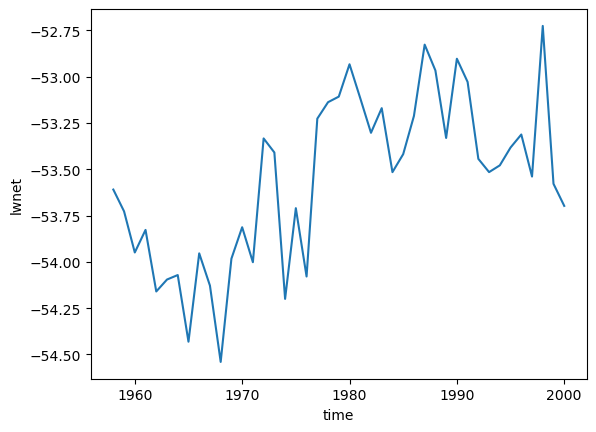

In [5]:
yearly_ds.lwnet.plot()

In [6]:
output_file = f"{PATH}{YEAR_START}_{YEAR_FIN}_yearly_weighted_means_no_ice_mask.nc"
yearly_ds.to_netcdf(output_file)

print(f"Yearly time series saved to {output_file}")

Yearly time series saved to /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl/MONTHLY/1958_2000_yearly_weighted_means_no_ice_mask.nc
